In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from common import plotting
from common.config import Params, results_dir
from common.data import generate_parameterized_dataset
from common.model import pde_mean_series
from common.surrogates import (
    ParameterizedSurrogateNN,
    Standardizer,
    SurrogateNN,
    solve_surrogate_ode,
    train_surrogate,
)

OUT = results_dir("zad3")

PARAMS = Params(D=0.1, p=0.01, q=1.0)
T_END = 15.0
NX = 100
DT = 1e-3


In [2]:
t_pde, u_pde_mean = pde_mean_series(PARAMS, T_END, DT, NX, init_kind="gaussian")

start = time.perf_counter()
sol_ode = solve_surrogate_ode(PARAMS.p, PARAMS.q, float(u_pde_mean[0]), [0, T_END])
ode_inference_ms = (time.perf_counter() - start) * 1000

t_ode = np.linspace(0, T_END, 100)
u_ode = sol_ode.sol(t_ode).T

print(f"ODE inference time: {ode_inference_ms:.4f} ms")


ODE inference time: 0.5996 ms


In [3]:
X_raw = torch.tensor(t_pde, dtype=torch.float32).view(-1, 1)
y = torch.tensor(u_pde_mean, dtype=torch.float32).view(-1, 1)

t_mean, t_std = X_raw.mean(), X_raw.std()
X = (X_raw - t_mean) / t_std

model = SurrogateNN()
train_surrogate(model, X, y, epochs=2000, lr=0.01, batch_size=None, log_every=200)

start = time.perf_counter()
with torch.no_grad():
    t_norm = (torch.tensor(t_ode, dtype=torch.float32).view(-1, 1) - t_mean) / t_std
    u_nn_pred = model(t_norm).numpy()
nn_inference_ms = (time.perf_counter() - start) * 1000

print(f"NN inference time: {nn_inference_ms:.4f} ms")


Epoch [200/2000], Loss: 0.000008
Epoch [400/2000], Loss: 0.000002
Epoch [600/2000], Loss: 0.000001
Epoch [800/2000], Loss: 0.000001
Epoch [1000/2000], Loss: 0.000001
Epoch [1200/2000], Loss: 0.000001
Epoch [1400/2000], Loss: 0.000000
Epoch [1600/2000], Loss: 0.000000
Epoch [1800/2000], Loss: 0.000000
Epoch [2000/2000], Loss: 0.000000
NN inference time: 0.1639 ms


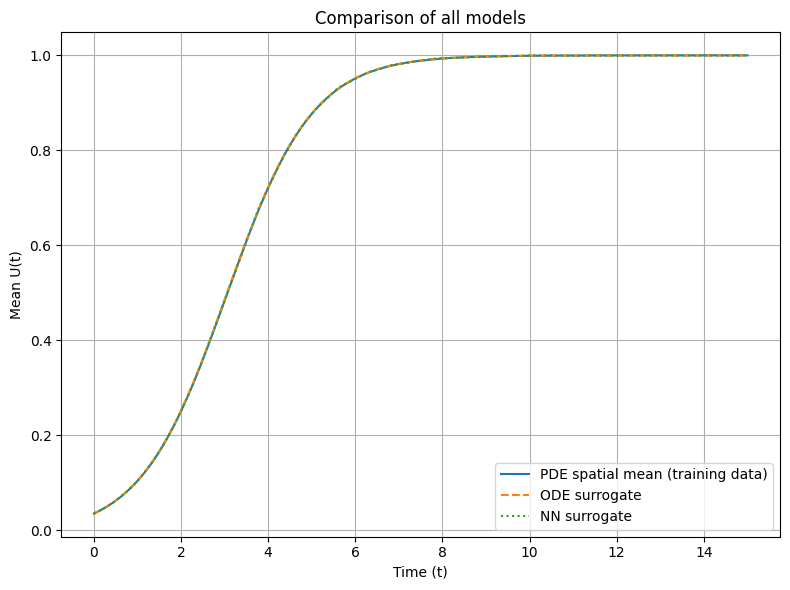

59

In [4]:
plt.figure(figsize=(8, 6))
plt.plot(t_pde, u_pde_mean, label="PDE spatial mean (training data)")
plt.plot(t_ode, u_ode, label="ODE surrogate", linestyle="--")
plt.plot(t_ode, u_nn_pred, label="NN surrogate", linestyle=":")
plt.title("Comparison of all models")
plt.xlabel("Time (t)")
plt.ylabel("Mean U(t)")
plt.grid(True)
plt.legend()
plotting.savefig(OUT / "comparison_plot.png", dpi=300)
plt.show()

(OUT / "inference_times.txt").write_text(
    f"ODE inference time: {ode_inference_ms:.4f} ms\n"
    f"NN inference time: {nn_inference_ms:.4f} ms\n"
)


In [5]:
X_multi, y_multi = generate_parameterized_dataset(num_simulations=20, tend=T_END, dt=DT, nx=NX)
print(f"Generated {X_multi.shape[0]} data points.")


Generated 300000 data points.


In [6]:
perm = np.random.default_rng(0).permutation(len(X_multi))
n_train = int(0.8 * len(X_multi))
train_idx, val_idx = perm[:n_train], perm[n_train:]

X_train_np, y_train_np = X_multi[train_idx], y_multi[train_idx]
X_val_np, y_val_np = X_multi[val_idx], y_multi[val_idx]

x_stdz = Standardizer.fit(X_train_np)
y_stdz = Standardizer.fit(y_train_np)

X_train = torch.tensor(x_stdz.apply(X_train_np), dtype=torch.float32)
y_train = torch.tensor(y_stdz.apply(y_train_np), dtype=torch.float32)
X_val = torch.tensor(x_stdz.apply(X_val_np), dtype=torch.float32)
y_val = torch.tensor(y_stdz.apply(y_val_np), dtype=torch.float32)

model_general = ParameterizedSurrogateNN()
train_surrogate(model_general, X_train, y_train, epochs=100, lr=1e-3, weight_decay=1e-5, batch_size=256, log_every=10)


Epoch [10/100], Loss: 0.001962
Epoch [20/100], Loss: 0.000206
Epoch [30/100], Loss: 0.001106
Epoch [40/100], Loss: 0.000477
Epoch [50/100], Loss: 0.000136
Epoch [60/100], Loss: 0.000178
Epoch [70/100], Loss: 0.000213
Epoch [80/100], Loss: 0.000093
Epoch [90/100], Loss: 0.002270
Epoch [100/100], Loss: 0.000020


Test parameters: D=0.02, p=0.079, q=6.68


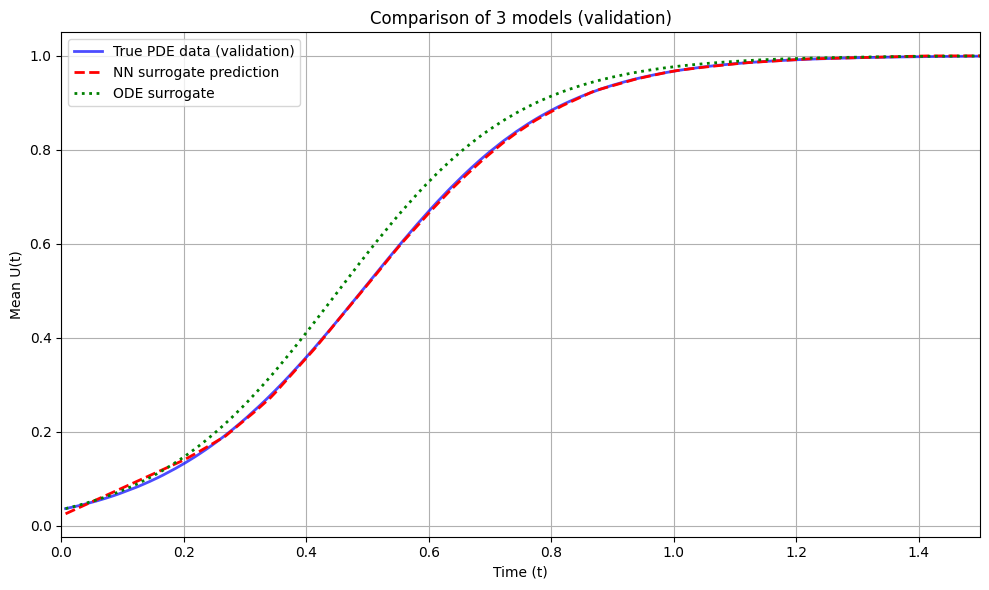

In [7]:
unique_params = np.unique(X_val_np[:, 1:], axis=0)
D_test, p_test, q_test = unique_params[0]
print(f"Test parameters: D={D_test:.2f}, p={p_test:.3f}, q={q_test:.2f}")

mask = (
    (np.abs(X_val_np[:, 1] - D_test) < 1e-6)
    & (np.abs(X_val_np[:, 2] - p_test) < 1e-6)
    & (np.abs(X_val_np[:, 3] - q_test) < 1e-6)
)
X_test_sample = X_val_np[mask]
y_test_sample = y_val_np[mask]
order = np.argsort(X_test_sample[:, 0])
X_test_sample, y_test_sample = X_test_sample[order], y_test_sample[order]

with torch.no_grad():
    y_pred = y_stdz.invert(model_general(torch.tensor(x_stdz.apply(X_test_sample), dtype=torch.float32)).numpy())

sol_ode_test = solve_surrogate_ode(
    p_test, q_test, float(y_test_sample[0, 0]),
    [X_test_sample[0, 0], X_test_sample[-1, 0]], t_eval=X_test_sample[:, 0],
)
u_ode_test = sol_ode_test.y.T

plt.figure(figsize=(10, 6))
plt.plot(X_test_sample[:, 0], y_test_sample, label="True PDE data (validation)", color="blue", linewidth=2, alpha=0.7)
plt.plot(X_test_sample[:, 0], y_pred, label="NN surrogate prediction", color="red", linestyle="--", linewidth=2)
plt.plot(sol_ode_test.t, u_ode_test, label="ODE surrogate", color="green", linestyle=":", linewidth=2)
plt.title("Comparison of 3 models (validation)")
plt.xlabel("Time (t)")
plt.ylabel("Mean U(t)")
plt.legend()
plt.xlim(0, 1.5)
plt.grid(True)
plotting.savefig(OUT / "comparison_3_models_validation.png", dpi=300)
plt.show()
